In [1]:
!pip install git+https://github.com/Abiyzelalem27/bell_state.git

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
  Cloning https://github.com/Abiyzelalem27/bell_state.git to /tmp/pip-req-build-ejszmzfx
  Running command git clone --filter=blob:none --quiet https://github.com/Abiyzelalem27/bell_state.git /tmp/pip-req-build-ejszmzfx
  Resolved https://github.com/Abiyzelalem27/bell_state.git to commit 74519f7f9f8c21e4e1eb6c12eca3e13015b424a7
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [24]:
import numpy as np
import qutip as qt

from qutip import Bloch
from scipy.linalg import expm, eigh

import Comp_Quant_Dynam as cqd   # custom package
import bell_state as bs          # custom package

# Lecture 5

## 5.1 Spin \(1/2\) mathematical toolbox

### 5.1.1 Single spin \(1/2\)

### States

The Hilbert space of a single spin \(1/2\) system is

$$
\mathcal{H} = \text{span}\{|0\rangle, |1\rangle\} = \mathbb{C}^2
$$

A general state is written as

$$
|\psi\rangle = c_0 |0\rangle + c_1 |1\rangle,
\qquad
c_i \in \mathbb{C}
$$

with normalization condition

$$
|c_0|^2 + |c_1|^2 = 1
$$

This is a general pure state of a spin \(1/2\) system (qubit).

Although the state is specified by two complex numbers (four real parameters), normalization and the irrelevance of a global phase reduce the number of physical parameters to two.

Indeed,

$$
|\tilde{\psi}\rangle = e^{i\alpha} |\psi\rangle,
\qquad
\alpha \in \mathbb{R}
$$

cannot be physically distinguished from

$$
|\psi\rangle
$$

Therefore, two real parameters are sufficient.

---

### Bloch sphere parametrization

A convenient parametrization is

$$
|\psi\rangle
=
\cos\left(\frac{\theta}{2}\right)|0\rangle
+
e^{i\phi}
\sin\left(\frac{\theta}{2}\right)|1\rangle
$$

with

$$
\theta \in [0,\pi],
\qquad
\phi \in [0,2\pi]
$$

The state can therefore be visualized on the Bloch sphere.

Each pair \((\theta,\phi)\) corresponds uniquely to a point on the unit sphere.

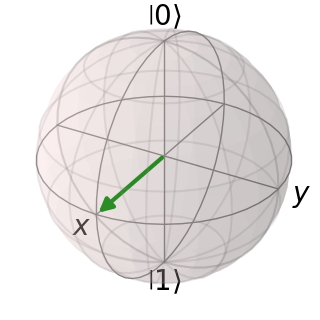

In [25]:
# Example: state along the X-axis
theta = np.pi / 2 #theta: angle from the z-axis [0, pi]
phi = 0  #  phi: azimuthal angle [0, 2pi]
psi = cqd.utility.create_qubit_state(theta, phi)
# Visualize on the Bloch sphere
b = Bloch(figsize=(3, 3))
b.add_states(psi)
b.show()

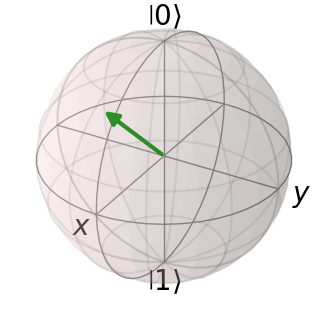

In [26]:
#state 
theta = np.pi / 4
phi = 270
psi = cqd.utility.create_qubit_state(theta, phi)
# Visualize on the Bloch sphere
#Bloch visualization
b = Bloch(figsize=(3, 3))
b.add_states(psi)
b.show()

In [27]:
#Pauli-operators
H = cqd.hamiltonians.hermitian_operator(1, 0.5, 0.2, -1)
print("H=\n", H)
print()
# Hermitian conjugate
H_dagger = H.conj().T
print("H† =\n", H_dagger)
print()
# Check equality
print(np.allclose(H, H_dagger))

H=
 [[0. +0.j  0.5-0.2j]
 [0.5+0.2j 2. +0.j ]]

H† =
 [[0. -0.j  0.5-0.2j]
 [0.5+0.2j 2. -0.j ]]

True


In [28]:
#Pauli-operators
H = cqd.hamiltonians.hermitian_operator(1, 0, 0, 1)
print("H=\n", H)
print()
# Hermitian conjugate
H_dagger = H.conj().T
print("H† =\n", H_dagger)
print()
# Check equality
print(np.allclose(H, H_dagger))

H=
 [[2.+0.j 0.+0.j]
 [0.+0.j 0.+0.j]]

H† =
 [[2.-0.j 0.-0.j]
 [0.-0.j 0.-0.j]]

True


In [29]:
#Pauli-operators
H = cqd.hamiltonians.hermitian_operator(1, 1, 1, 1)
print("H=\n", H)
print()
# Hermitian conjugate
H_dagger = H.conj().T
print("H† =\n", H_dagger)
print()
# Check equality
print(np.allclose(H, H_dagger))

H=
 [[2.+0.j 1.-1.j]
 [1.+1.j 0.+0.j]]

H† =
 [[2.-0.j 1.-1.j]
 [1.+1.j 0.-0.j]]

True


Rx:
 [[0.8660254+0.j  0.       -0.5j]
 [0.       -0.5j 0.8660254+0.j ]]
Initial state = [1 0]

Evolved state = [ 0.72827555-0.58913884j -0.27214547+0.2201522j ]


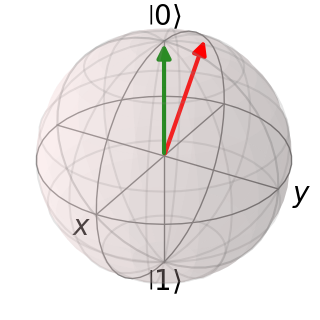

In [30]:
# Parameters
Omega = 1
t = np.pi / 2
theta = np.pi / 3  
axis = [1, 0, 0] 
Rx = bs.operators.rotation_gate(theta, axis)
print("Rx:\n", Rx)
# Hamiltonian
H = (Omega / 2) * Rx

# Unitary evolution 
U = expm(-1j * H * t)

# Initial state 
psi0 = np.array([1, 0])
psi_t = U @ psi0/np.linalg.norm(U @ psi0) #normalized the sate 

# Time evolved state
print("Initial state =", psi0)
print()
print("Evolved state =", psi_t)



# Convert to Qobj for Bloch visualization
initial_Qobj = qt.Qobj(psi0)
final_Qobj = qt.Qobj(psi_t)

# Bloch sphere
b = Bloch(figsize=(3,3))
b.add_states([initial_Qobj, final_Qobj])
b.vector_color = ['green', 'red']
b.show()

Ry=
 [[ 0.92387953+0.j -0.38268343+0.j]
 [ 0.38268343+0.j  0.92387953+0.j]]
Initial state=
 [0 1]

Evolved state=
 [0.09021806+0.17172074j 0.86844597-0.4562612j ]


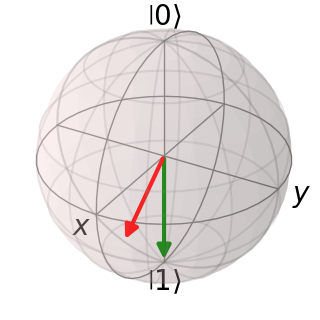

In [31]:
# Parameters
Omega = 1
t = np.pi / 3
theta = np.pi / 4  
axis=[0, 1, 0]
Ry = bs.operators.rotation_gate(theta, axis)
print("Ry=\n", Ry)

# Hamiltonian 
H = (Omega / 2) * Ry

# Unitary evolution operator
U = expm(-1j * H * t)

#state
psi0 = np.array([0, 1])
psi_t = U @ psi0/np.linalg.norm(U @ psi0) 

print("Initial state=\n", psi0)
print()
print("Evolved state=\n", psi_t)
# Convert to Qobj for Bloch visualization
initial_Qobj= qt.Qobj(psi0)
final_Qobj= qt.Qobj(psi_t)

# Bloch sphere
b = Bloch(figsize=(3, 3))
b.add_states([initial_Qobj, final_Qobj])
b.vector_color = ['green', 'red']
b.show()

Initial state=
 [0.+0.j 1.+0.j]

Evolved state=
 [0.        +0.j         0.74809259-0.66359436j]


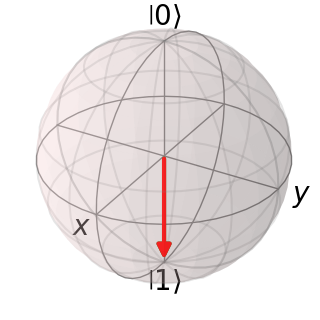

In [32]:
Omega = 1
t = np.pi / 2
theta = np.pi / 4  
axis=[0, 0, 1]
Rz = bs.operators.rotation_gate(theta, axis)
H = (Omega / 2) * Rz

# Unitary evolution operator
U = expm(-1j * H * t)
psi0 = np.array([0, 1], dtype=complex)
psi_t = U @ psi0/np.linalg.norm(U @ psi0)

print("Initial state=\n", psi0)
print()
print("Evolved state=\n", psi_t)
# Convert to Qobj for Bloch visualization
initial_Qobj= qt.Qobj(psi0)
final_Qobj= qt.Qobj(psi_t)

# Bloch sphere
b = Bloch(figsize=(3, 3))
b.add_states([initial_Qobj, final_Qobj])
b.vector_color=['green', 'red']
b.show()

# Operators

## Hermitian operators (Hamiltonians / observables)

$$
H = \vec{\lambda}\cdot\vec{\sigma}
= \sum_{i=0}^{3} \lambda_i \sigma_i
$$

where

$$
\sigma_0 = \mathbb{I},
\qquad
\sigma_1 = \sigma_x,
\qquad
\sigma_2 = \sigma_y,
\qquad
\sigma_3 = \sigma_z
$$

These are the Pauli operators.

The spin operators are

$$
S_i = \frac{1}{2}\sigma_i,
\qquad (i=1,2,3)
$$

or equivalently

$$
\vec{S} = \frac{1}{2}\vec{\sigma}
$$

---

## Unitary operators (evolution operators / rotations)

Time evolution is generated by

$$
U = e^{-iHt}
$$

Note that

$$
|\psi\rangle \rightarrow e^{-it}|\psi\rangle
$$

is only an irrelevant global phase.

Therefore, global energy shifts in \(H\) are physically irrelevant.

A general unitary can be written as

$$
U = e^{-it\sum_{i=1}^{3} n_i \sigma_i}
$$

with

$$
|\vec n| = 1
$$

which parameterizes all relevant unitary operations.

We can also write

$$
U = e^{\,i\vec v\cdot\vec\sigma}
$$

with a general vector

$$
\vec v \in \mathbb{R}^3
$$

but using \(t\) and \(\vec n\) is convenient because they can be interpreted as a rotation angle and rotation axis on the Bloch sphere.

---

## SU(2)

The relevant symmetry group is the special unitary group

$$
SU(2)
$$

with generators

$$
\sigma_i,
\qquad (i=1,2,3)
$$

satisfying the algebra

$$
[\sigma_i,\sigma_j]
=
2i\,\epsilon_{ijk}\sigma_k
$$

---

## Exercise

Calculate the time evolution of \(|0\rangle\) under

$$
H = \Omega S_x
$$

and visualize it on the Bloch sphere.

evals= [1.11022302e-16 1.41421356e+00]

evecs=
 [[-0.70710678+0.j         -0.70710678+0.j        ]
 [ 0.        -0.70710678j  0.        +0.70710678j]]
psi_t =
 [-0.36687233-0.48195127j -0.48195127-0.63312767j]
norm = 0.9999999999999998


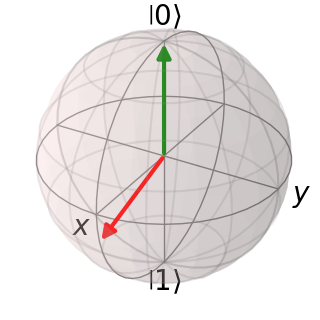

In [33]:
Omega = 1
t = np.pi 

# Rotation angle and axis
theta = np.pi / 2  
axis = [1, 0, 0] 

# Rotation gate Rx and Hamiltonian
Rx = bs.operators.rotation_gate(theta, axis)
H = Omega * Rx
psi0 = np.array([1, 0], dtype=complex)

# Diagonalize H
evals, evecs = eigh(H)

print("evals=", evals)
print()
print("evecs=\n", evecs)

# define the init_coeffs of state psi0 in the eigenbasis
# |0> = (1/sqrt(2))|E0> + (1/sqrt(2))|E1>
init_coeffs = np.zeros(evals.size)
init_coeffs[0] = 1 / np.sqrt(2)
init_coeffs[1] = 1 / np.sqrt(2)

# Time evolution in eigenbasis
psi_t = cqd.unitaries.t_evol_eigenbasis(init_coeffs, t, evals, evecs)

# print evolved state
print("psi_t =\n", psi_t)

# normalization of the state
print("norm =", np.linalg.norm(psi_t))

# Convert to QuTiP objects
initial_Qobj = qt.Qobj(psi0)

# use the full evolved state vector
final_Qobj = qt.Qobj(psi_t)

# Bloch sphere visualization
# initial state -> green
# final state -> red
b = Bloch(figsize=(3,3))

b.add_states([initial_Qobj, final_Qobj])

b.vector_color = ['green', 'red']

b.show()

evals= [1.11022302e-16 1.41421356e+00]

evecs=
 [[-0.70710678+0.j         -0.70710678+0.j        ]
 [ 0.        -0.70710678j  0.        +0.70710678j]]


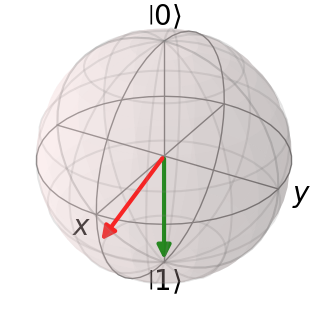

In [34]:
Omega = 1
t = np.pi 
theta = np.pi / 2  
axis = [1, 0, 0] 
Rx = bs.operators.rotation_gate(theta, axis)
H = Omega * Rx

# Diagonalize H
evals, evecs = eigh(H)
print("evals=", evals)
print()
print("evecs=\n", evecs)

# calculate the coefficients of psi0 in the eigenbasis
init_coeffs = np.zeros(evals.size)
init_coeffs[0] = 1 / np.sqrt(2)
init_coeffs[1] = 1 / np.sqrt(2)

# Initial state and evolved state in the eigenbasis
psi0 = np.array([0, 1], dtype=complex)
psi_t = cqd.unitaries.t_evol_eigenbasis(init_coeffs, t, evals, evecs)

# Convert to QuTiP objects
initial_Qobj = qt.Qobj(psi0)
final_Qobj = qt.Qobj(psi_t)

# Bloch sphere visualization initial state -> green and  final state -> red
b = Bloch(figsize=(3,3))
b.add_states([initial_Qobj, final_Qobj])
b.vector_color = ['green', 'red']

b.show()

Generally,

$$
e^{-i \frac{\theta}{2}\,\hat{n}\cdot \sigma}
$$

represents a rotation around the axis $\hat{n}$ by an angle $\theta$ on the Bloch sphere.

$$
U(\theta,\hat{n}) = e^{-i \frac{\theta}{2}\,\hat{n}\cdot \sigma}
$$

Note:

$$
e^{-i \frac{2\pi}{2}\sigma_a}
=
e^{-i \pi \sigma_a}
=
-I
$$

so a $2\pi$ rotation gives a global phase $-1$.

A $4\pi$ rotation is needed to return exactly to the original spinor state.

This is called the **double covering** of the Bloch sphere (or of $SO(3)$ by $SU(2)$).

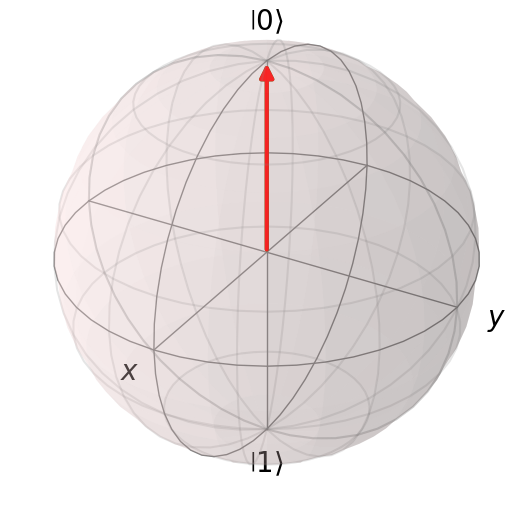

In [35]:
Omega = 1
t = np.pi 
theta = 2 * np.pi  
axis = [0, 1, 0] 
Rx = bs.operators.rotation_gate(theta, axis)
psi0 = np.array([1, 0], dtype=complex)
psi_t = Rx @ psi0

# Convert NumPy to QuTiP visualitions in Bloch spheres
initial_Qobj = qt.Qobj(psi0)
final_Qobj = qt.Qobj(psi_t)

# Bloch sphere visualization initial state -> green and  final state -> red
b = Bloch(figsize=(5,5))
b.add_states([initial_Qobj, final_Qobj])
b.vector_color = ['green', 'red']

b.show()

# Multiple Spins

For a system of \(N\) spins, the Hilbert space is

$$
\mathcal{H} = \mathbb{C}^2 \otimes \mathbb{C}^2 \otimes \cdots \otimes \mathbb{C}^2
= (\mathbb{C}^2)^{\otimes N}
$$

The dimension of the Hilbert space is

$$
\dim(\mathcal{H}) = 2^N
$$

For two spins:

$$
\mathcal{H} = \text{span}\{ |00\rangle, |01\rangle, |10\rangle, |11\rangle \}
$$

A general state is written as

$$
|\psi\rangle = \sum_{\alpha} c_{\alpha} |\alpha\rangle
$$

where the multi-index is

$$
\alpha = (i_1,i_2,\dots,i_N), \qquad i_k \in \{0,1\}
$$

Operators acting on multiple spins are constructed using tensor products.

Example:

$$
\sigma_z^{(1)} \otimes \sigma_z^{(2)}
$$

For local operators, we typically act non-trivially only on a few spins.

Example Hamiltonian:

$$
H = \sum_{i<j} J_{ij}\,\sigma_z^{(i)}\sigma_z^{(j)}
$$

which describes two-body interaction terms.

In [39]:
# Two-spin Hilbert space
# H = C^2 ⊗ C^2 = C^4
# basis = {|00>, |01>, |10>, |11>}
# Tensor products
# sigma_z^(1) ⊗ sigma_z^(2)
theta = np.pi / 2  
n1 = [1, 0, 0] 
n2 = [0, 1, 0] 
n3 = [0, 0, 1] 
I = np.eye(2, dtype=complex)
Rx = bs.operators.rotation_gate(theta, n1)
Ry = bs.operators.rotation_gate(theta, n2)
Rz = bs.operators.rotation_gate(theta, n3)

SzSz = np.kron(Rz, Rz)
print("sigma_z ⊗ sigma_z =\n", SzSz)
# sigma_x^(1) ⊗ I
Sx1 = np.kron(Rx, I)
print("\nsigma_x^(1) ⊗ I =\n", Sx1)
# I ⊗ sigma_x^(2)
Sx2 = np.kron(I, Rx)
print("I ⊗ sigma_x^(2) =\n", Sx2)

# Example Hamiltonian
# H = J sigma_z^(1) sigma_z^(2)
J = 1
H = J * np.kron(Rz, Rz)
print("\nHamiltonian H =\n", H)


sigma_z ⊗ sigma_z =
 [[1.79380389e-16-1.00000000e+00j 0.00000000e+00+0.00000000e+00j
  0.00000000e+00+0.00000000e+00j 0.00000000e+00+0.00000000e+00j]
 [0.00000000e+00+0.00000000e+00j 1.00000000e+00-1.01465364e-17j
  0.00000000e+00+0.00000000e+00j 0.00000000e+00+0.00000000e+00j]
 [0.00000000e+00+0.00000000e+00j 0.00000000e+00+0.00000000e+00j
  1.00000000e+00+1.01465364e-17j 0.00000000e+00+0.00000000e+00j]
 [0.00000000e+00+0.00000000e+00j 0.00000000e+00+0.00000000e+00j
  0.00000000e+00+0.00000000e+00j 1.79380389e-16+1.00000000e+00j]]

sigma_x^(1) ⊗ I =
 [[0.70710678+0.j         0.        +0.j         0.        -0.70710678j
  0.        +0.j        ]
 [0.        +0.j         0.70710678+0.j         0.        +0.j
  0.        -0.70710678j]
 [0.        -0.70710678j 0.        +0.j         0.70710678+0.j
  0.        +0.j        ]
 [0.        +0.j         0.        -0.70710678j 0.        +0.j
  0.70710678+0.j        ]]
I ⊗ sigma_x^(2) =
 [[0.70710678+0.j         0.        -0.70710678j 0.        

# 5.2 Collective spin models

$$
H
=
J \sum_{i<j} \sigma_z^{(i)} \sigma_z^{(j)}
+
h \sum_i \sigma_x^{(i)}
$$

This is an all-to-all Ising model with transverse field.

A special case is the Lipkin–Meshkov–Glick (LMG) model.

---

### Note

All interactions are equal \(\Rightarrow\) permutation symmetry.

If the initial state is invariant under exchange of two spins, it remains symmetric throughout the dynamics.

Therefore, it is sufficient to restrict the Hilbert space to permutation-invariant states.

This greatly reduces the Hilbert-space dimension.

Example:

$$
|00\cdots0\rangle
\quad \Rightarrow \quad N+1 \text{ states}
$$

instead of

$$
2^N
$$

states.

---

# Collective spin operators

Define the collective spin operators as

$$
S_\alpha
=
\sum_{i=1}^{N} S_\alpha^{(i)}
=
\sum_{i=1}^{N} \frac{\sigma_\alpha^{(i)}}{2}
\qquad
(\alpha=x,y,z)
$$

For example,

$$
S_x
=
\sum_i \frac{\sigma_x^{(i)}}{2}
$$

and

$$
S_z
=
\sum_i \frac{\sigma_z^{(i)}}{2}
$$

---

Using

$$
S_z^2
=
\left(
\sum_i \frac{\sigma_z^{(i)}}{2}
\right)^2
$$

we obtain

$$
S_z^2
=
\sum_i \frac{(\sigma_z^{(i)})^2}{4}
+
\sum_{i<j}
\frac{\sigma_z^{(i)}\sigma_z^{(j)}}{2}
$$

Since

$$
(\sigma_z^{(i)})^2 = I
$$

the interaction term can be rewritten in terms of collective operators.

---

Thus, the LMG Hamiltonian becomes

$$
H
=
4J S_z^2
+
2h S_x
$$

up to constant energy shifts.

Equivalently,

$$
H
=
4J S_z^2
-
N J
+
2h S_x
$$

Usually the constant term

$$
-NJ
$$

is included to make the energy density extensive.

---

# Dicke basis

The Dicke states diagonalize \(S_z\):

$$
S_z |k\rangle
=
\frac{1}{2}(N-2k)|k\rangle
$$

with

$$
k = 0,1,\dots,N
$$

An alternative notation is

$$
|k\rangle \rightarrow |S,M\rangle
$$

with

$$
M = \frac{N}{2}-k,
\qquad
S = \frac{N}{2}
$$

These states are eigenstates of the collective spin operators and are widely used in collective spin models.

# Matrix form of \(S_x\) in the Dicke basis

Using the ladder operators,

$$
S_x = \frac{S_+ + S_-}{2}
$$

The operator \(S_x\) is tridiagonal since it only couples neighboring Dicke states:

$$
\langle k'|S_x|k\rangle \neq 0
\quad \text{only if} \quad
k' = k \pm 1
$$

The ladder operators act as

$$
S_+ |k\rangle
=
\sqrt{(N-k)(k+1)}
\,|k+1\rangle
$$

and

$$
S_- |k\rangle
=
\sqrt{k(N-k+1)}
\,|k-1\rangle
$$

---

# Physics of the LMG model

## Ferromagnetic phase

For

$$
\Omega \ll J
$$

the interaction term dominates and the spins remain aligned.

The Hamiltonian is approximately

$$
H \simeq -N S_z^2 - 2\Omega S_x
$$

The ground state is approximately

$$
|GS\rangle
=
\frac{|00\cdots0\rangle + |11\cdots1\rangle}{\sqrt{2}}
$$

which is a GHZ-type state.

---

## Paramagnetic phase

For

$$
\Omega \gg J
$$

the transverse field dominates and all spins align along the \(x\)-direction.

The ground state becomes

$$
|GS\rangle
=
|+\rangle^{\otimes N}
=
\frac{1}{2^{N/2}}
\sum_k |k\rangle
$$

which is a spin-coherent product state.

---

## Phase transition

At

$$
\Omega = J
$$

a quantum phase transition occurs.

The critical Hamiltonian allows strong quantum fluctuations and enhanced entanglement.

The gap closes in the thermodynamic limit:

$$
N \to \infty
$$

---

# Dynamics

Consider the initial state

$$
|\psi_0\rangle = |S,S\rangle
$$

The interaction term tends to keep spins aligned along \(z\), while the transverse field rotates them.

For

$$
\Omega \ll J
$$

the system behaves collectively and remains ordered.

For

$$
\Omega \gg J
$$

the field dominates and spins align with \(S_x\).

Near

$$
\Omega \simeq J
$$

critical dynamical behavior appears.

---

# Time evolution

The evolved state is

$$
|\psi(t)\rangle
=
e^{-iHt}
|\psi_0\rangle
=
\sum_k e^{-iE_k t}
\langle E_k|\psi_0\rangle
|E_k\rangle
$$

The expectation value of an observable \(O\) is

$$
\langle O(t)\rangle
=
\sum_{j,k}
e^{-it(E_j-E_k)}
\langle\psi_0|E_j\rangle
\langle E_j|O|E_k\rangle
\langle E_k|\psi_0\rangle
$$

The long-time average becomes

$$
\overline{\langle O(t)\rangle}
=
\lim_{T\to\infty}
\frac{1}{T}
\int_0^T dt\,\langle O(t)\rangle
$$

which removes off-diagonal oscillating terms.

---

# Order parameter

The collective magnetization is

$$
\langle S_z^2 \rangle
=
\begin{cases}
S^2, & \Omega < \Omega_c \\
0, & \Omega > \Omega_c
\end{cases}
$$

in the thermodynamic limit.